# Predicting F1 Pit Stops

In [1]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

## Data Read

In [2]:
# Kaggle Notebook
# df_train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
# df_test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')

# local 
data_path = "/mnt/e/Kaggle_F1_Pit_Stops"
train_dp = os.path.join(data_path, "train.csv")
test_dp = os.path.join(data_path, "test.csv")

df_train = pd.read_csv(train_dp)
df_test = pd.read_csv(test_dp)

In [3]:
df_train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
df_train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

## Data Analysis

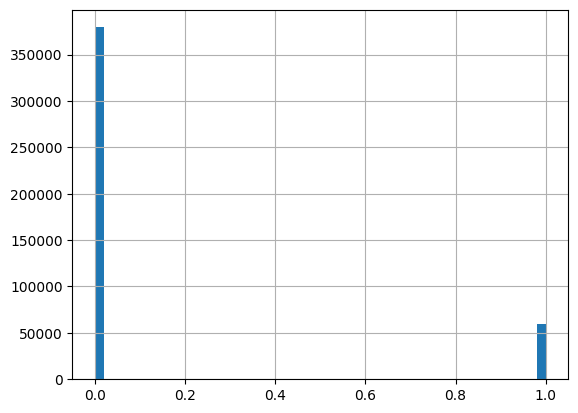

In [6]:
df_train['PitStop'].hist(bins=50)
plt.show()

In [7]:
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns

corr = df_train[numeric_cols].corr()

corr['PitStop'].sort_values(ascending=False)

PitStop                   1.000000
Stint                     0.143869
LapNumber                 0.111431
Position                  0.093536
Year                      0.090767
RaceProgress              0.059177
PitNextLap                0.048567
id                       -0.000214
LapTime (s)              -0.000437
LapTime_Delta            -0.008458
Cumulative_Degradation   -0.088052
Position_Change          -0.107659
TyreLife                 -0.134678
Name: PitStop, dtype: float64

In [8]:
# for col in numeric_cols[:10]:
#     plt.figure(figsize=(6,3))
#     df_train[col].hist(alpha=0.5, label='train')
#     df_test[col].hist(alpha=0.5, label='test')
#     plt.legend()
#     plt.title(col)
#     plt.show()

## Random Forest Model

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

### Dataset Preprocessing

In [10]:
TARGET = 'PitNextLap'

dset_train = df_train.copy()
dset_test = df_test.copy()

X = dset_train.drop(columns=[TARGET, 'id'])
y = dset_train[TARGET]

X_test = dset_test.drop(columns=['id'])

In [11]:
cat_cols = X.select_dtypes(include='object').columns

for col in cat_cols:

    le = LabelEncoder()

    full_data = pd.concat([
        X[col],
        X_test[col]
    ]).astype(str)

    le.fit(full_data)

    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

### Model Train and Test

In [12]:
# training and test setup
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof = np.zeros(len(X))
preds = np.zeros(len(X_test))

In [13]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    # # Random Forest
    # model = RandomForestClassifier(
    #     n_estimators=500,
    #     max_depth=15,
    #     min_samples_leaf=5,
    #     n_jobs=-1,
    #     random_state=42,
    #     class_weight='balanced'
    # )

    # Extra Trees
    model = ExtraTreesClassifier(
        n_estimators=1000,
        max_depth=None,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=False,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced'
    )


    # train
    model.fit(X_train, y_train)

    # valid
    valid_pred = model.predict_proba(X_valid)[:,1]
    oof[valid_idx] = valid_pred
    score = roc_auc_score(y_valid, valid_pred)
    print(f'Fold {fold + 1}: {score:.5f}')

    # test
    preds += model.predict_proba(X_test)[:,1] / 5

Fold 1: 0.94252
Fold 2: 0.94030
Fold 3: 0.94158
Fold 4: 0.94028
Fold 5: 0.94146


In [14]:
submission = pd.DataFrame({
    'id': df_test['id'],
    'PitNextLap': preds
})

preds_save_path = os.path.join(data_path, 'submission.csv')
submission.to_csv(preds_save_path, index=False)